In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv('data.csv')

# Dataset Overview

In [ ]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(dataset.shape)

(7043, 21)


In [ ]:
for col in dataset.columns:
    print(f"\n{col}:")
    print(dataset[col].unique())


customerID:
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

gender:
['Female' 'Male']

SeniorCitizen:
[0 1]

Partner:
['Yes' 'No']

Dependents:
['No' 'Yes']

tenure:
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]

PhoneService:
['No' 'Yes']

MultipleLines:
['No phone service' 'No' 'Yes']

InternetService:
['DSL' 'Fiber optic' 'No']

OnlineSecurity:
['No' 'Yes' 'No internet service']

OnlineBackup:
['Yes' 'No' 'No internet service']

DeviceProtection:
['No' 'Yes' 'No internet service']

TechSupport:
['No' 'Yes' 'No internet service']

StreamingTV:
['No' 'Yes' 'No internet service']

StreamingMovies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'One year' 'Two year']

PaperlessBilling:
['Yes' 'No']

PaymentMethod:
['Electronic check' 'Mailed check' 'Bank tr

Dữ liệu gồm có 7043 dòng và 21 cột


1.   Thông tin định danh
*   `customerID`: id của từng khách hàng.

2.  Thông tin nhân khẩu
*   `gender`: giới tính; `Male` hoặc `Famale`.

*   `SeniorCitizen`: Khách hàng có phải là người cao tuổi hay không; `0` hoặc `1`.
*   `Partner`: Khách hàng có vợ chồng hay là người sống chung hay không; `Yes` hoặc `No`.
*   `Dependents`: Khách hàng có người phụ thuộc (con cái, người thân); `Yes` hoặc `No`.

3.  Thông tin thời gian sử dụng
*   `tenure`: Số tháng khách hàng đã sử dụng dịch vụ.

4.  Dịch vụ điện thoại
*   `PhoneService`: Có đăng ký dịch vụ điện thoại không.

*   `MultipleLines`: Có dùng nhiều đường dây điện thoại không; `Yes` hoặc `No`,
`No phone service`: không dùng điện thoại.

5.  Dịch vụ Internet
*   `InternetService`: Loại Internet sử dụng; `DSL`, `Fiber optic` hoặc `No`.

*   `OnlineSecurity`: Có dịch vụ bảo mật trực tuyến không; `Yes`, `No` hoặc
`No internet service`.
*   `OnlineBackup`: Có dịch vụ sao lưu trực tuyến không; `Yes`, `No` hoặc
`No internet service`.
*   `DeviceProtection`: Có bảo vệ thiết bị không; `Yes`, `No` hoặc
`No internet service`.
*   `TechSupport`: Có hỗ trợ kỹ thuật không; `Yes`, `No` hoặc
`No internet service`.
*   `StreamingTV`: Có xem tivi trực tuyến không; `Yes`, `No` hoặc
`No internet service`.
*   `StreamingMovies`: Có xem phim trực tuyến không; `Yes`, `No` hoặc
`No internet service`.

6. Hợp đồng & Thanh toán
*   `Contract`: loại hợp đồng; `Month-to-month`, `One year` hoặc `Two year`.

*   `PaperlessBilling`: có dùng hóa đơn điện tử không; `Yes` hoặc `No`.
*   `PaymentMethod`: Phương thức thanh toán; `Electronic check`, `Mailed check`, `Bank transfer (automatic)` hoặc `Credit card (automatic)`

7.  Chi phí
*   `MonthlyCharges`: Phí dịch vụ khách hàng (USD).

*   `TotalCharges`: Tổng tiền đã chi trả từ khi sử dụng dịch vụ.
8.  Biến mục tiêu
*   `Churn`: Khách hàng có rời bỏ dịch vụ hay không`Yes` hoặc `No`.

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Chuyển TotalCharges sang numberic

In [ ]:
# Ép kiểu dữ liệu
dataset['TotalCharges'] = pd.to_numeric(dataset['TotalCharges'], errors='coerce')

In [ ]:
# Kiểm tra xem NaN xuất hiện ở đâu
dataset[dataset['TotalCharges'].isna()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [ ]:
# Chuyển các giá trị NaN sang 0
dataset['TotalCharges'] = dataset['TotalCharges'].fillna(0)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000




*   `tenure` số tháng đăng ký từ 0 đến 72 tháng

*   `TotalCharges` có chi phí trung bình là khoảng \$2279.734304 với giá trị trung bình là \$1394.55.



## Làm sạch dữ liệu

Sao chép ra một tập dữ liệu mới

In [ ]:
df = dataset.copy()

### Kiểm tra dữ liệu trùng lặp

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['customerID'].duplicated().sum()

np.int64(0)

### Kiểm tra thiếu dữ liệu

In [ ]:
df.isnull().sum()*100/df.shape[0]

,0
customerID,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


# Phân tích phân phối dữ liệu (EDA)

Bộ dữ liệu bao gồm

*   Biến dự đoán: `churn`
*   Biến phân loại: `customerID`, `gender`, `SeniorCitizen`, `Partner`, `Dependent`, `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaperlessBilling`, `PaymentMethod`
*   Biến số: `tenure`, `MonthlyCharges`, `TotalCharges`



In [ ]:
import seaborn as sns

## Biến dự đoán

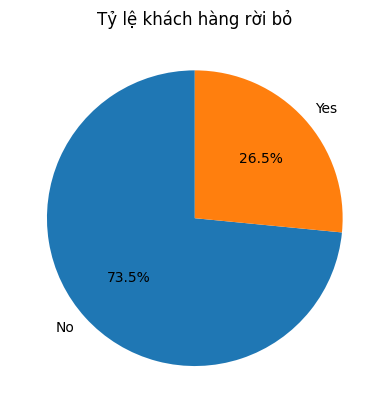

In [ ]:
df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Tỷ lệ khách hàng rời bỏ')
plt.ylabel('')
plt.show()

Đồ thị cho thấy phần lớn khách hàng vẫn tiếp tục sử dụng dịch vụ (73.5%), tuy nhiên tỷ lệ khách hàng rời bỏ chiếm 26.5%, cho thấy hiện tượng rời bỏ dịch vụ vẫn xảy ra khá phổ biến và là vấn đề cần được chú ý.

## Biến phân loại

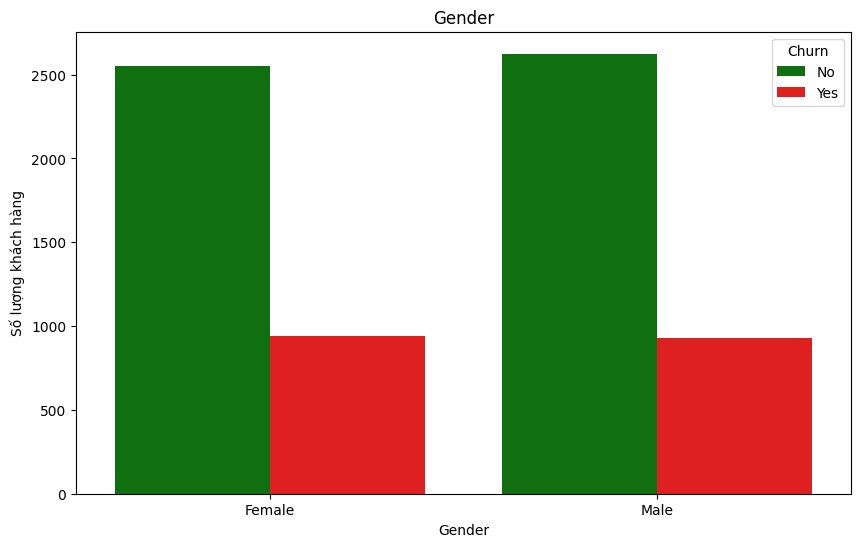

In [ ]:
colors = {'Yes': 'red', 'No': 'green'}
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x="gender", hue='Churn', palette=colors)
plt.title('Gender')
plt.xlabel("Gender")
plt.ylabel("Số lượng khách hàng")

for i in ax.containers:
  ax.bar_label(i, fmt='')

plt.show()

Tỷ lệ giữa người ở lại (No) và người rời đi (Yes) của nhóm Nam và Nữ là gần như tương đương.

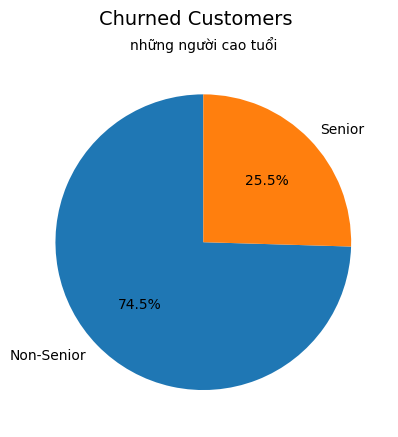

In [ ]:
senior_data = df[df['Churn']=='Yes']['SeniorCitizen'].map({1:'Senior',0:'Non-Senior'})
senior_data = senior_data.value_counts(normalize = True)
plt.pie(senior_data,autopct="%1.1f%%",startangle=90,labels=senior_data.index)
plt.suptitle('Churned Customers', fontsize=14)
plt.title('những người cao tuổi', fontsize=10)
plt.show()

Sự chênh lệnh của khách hàng về độ tuổi khách hàng -> đối tượng sử dụng dịch vụ hiện tại chủ yếu là người trẻ

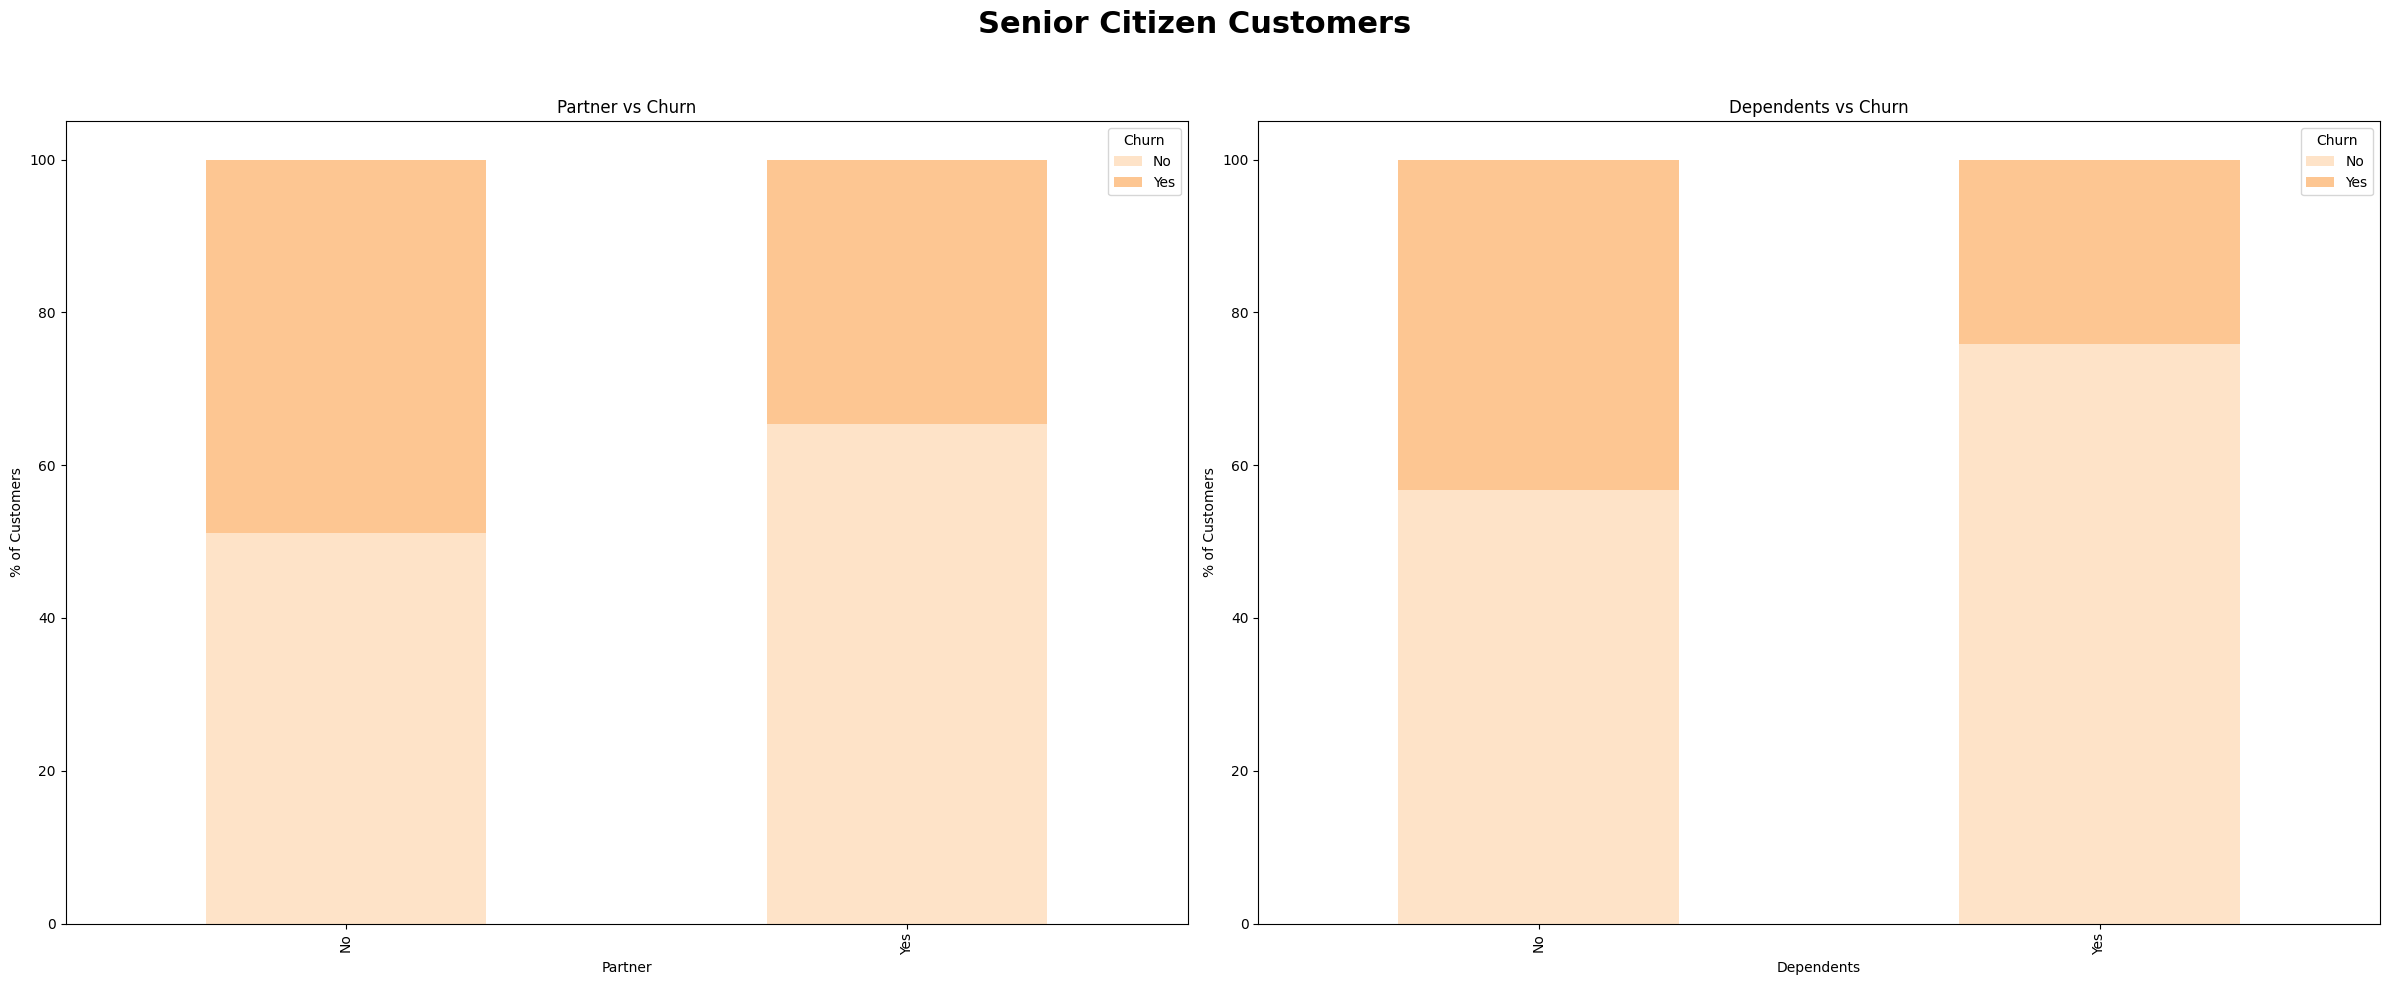

In [ ]:
colors = sns.color_palette('Oranges')
senior = df[df['SeniorCitizen']==1]

pct1 = pd.crosstab(senior['Partner'], senior['Churn'], normalize='index')*100
pct2 = pd.crosstab(senior['Dependents'], senior['Churn'], normalize='index')*100

fig, axes = plt.subplots(1, 2, figsize=(24,10))

pct1.plot(kind='bar', stacked=True, color=colors, ax=axes[0])
axes[0].set_title('Partner vs Churn')
axes[0].set_ylabel('% of Customers')
axes[0].legend(title='Churn',loc='upper right')

pct2.plot(kind='bar', stacked=True, color=colors, ax=axes[1])
axes[1].set_title('Dependents vs Churn')
axes[1].set_ylabel('% of Customers')
axes[1].legend(title='Churn',loc='upper right')

fig.suptitle('Senior Citizen Customers', fontsize=22, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

* Yếu tố Bạn đời (Partner): Những người cao tuổi có bạn đời (Partner: Yes) có tỷ lệ ở lại cao hơn rõ rệt so với những người độc thân. Điều này gợi ý rằng sự ổn định về gia đình giúp giảm khả năng rời bỏ dịch vụ.

* Yếu tố Người phụ thuộc (Dependents): Sự khác biệt ở đây thậm chí còn rõ ràng hơn. Nhóm người cao tuổi có người phụ thuộc (Dependents: Yes) có tỷ lệ rời bỏ thấp nhất trong các biểu đồ.

=> Mặc dù nhóm khách hàng trẻ chiếm số lượng rời bỏ lớn nhất (74.5%), nhưng ở nhóm người cao tuổi, mối quan hệ xã hội và gia đình (có bạn đời hoặc người phụ thuộc) đóng vai trò là 'chất keo' giữ chân khách hàng. Đây là một phát hiện quan trọng để mô hình có thể dự báo chính xác hơn bằng cách kết hợp giữa độ tuổi và tình trạng gia đình.

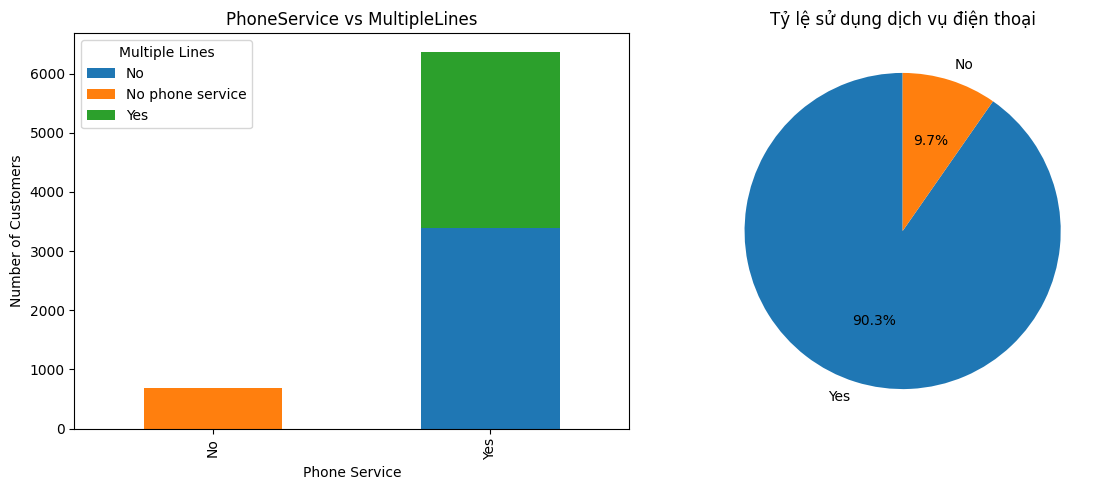

In [ ]:
stacked_data = (
    df.groupby(['PhoneService', 'MultipleLines'])
      .size()
      .unstack(fill_value=0)
)

phone_service_pct = df['PhoneService'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12,5))

stacked_data.plot(
    kind='bar',
    stacked=True,
    ax=axes[0]
)

axes[0].set_title('PhoneService vs MultipleLines')
axes[0].set_xlabel('Phone Service')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(title='Multiple Lines')

axes[1].pie(
    phone_service_pct,
    labels=phone_service_pct.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Tỷ lệ sử dụng dịch vụ điện thoại')

plt.tight_layout()
plt.show()

Dựa vào biểu đồ cho thấy tỷ lệ sử dụng điện thoại rất cao (90%)
Về số lượng người sử dụng dịch vụ MultipleLines cũng ngang nhau

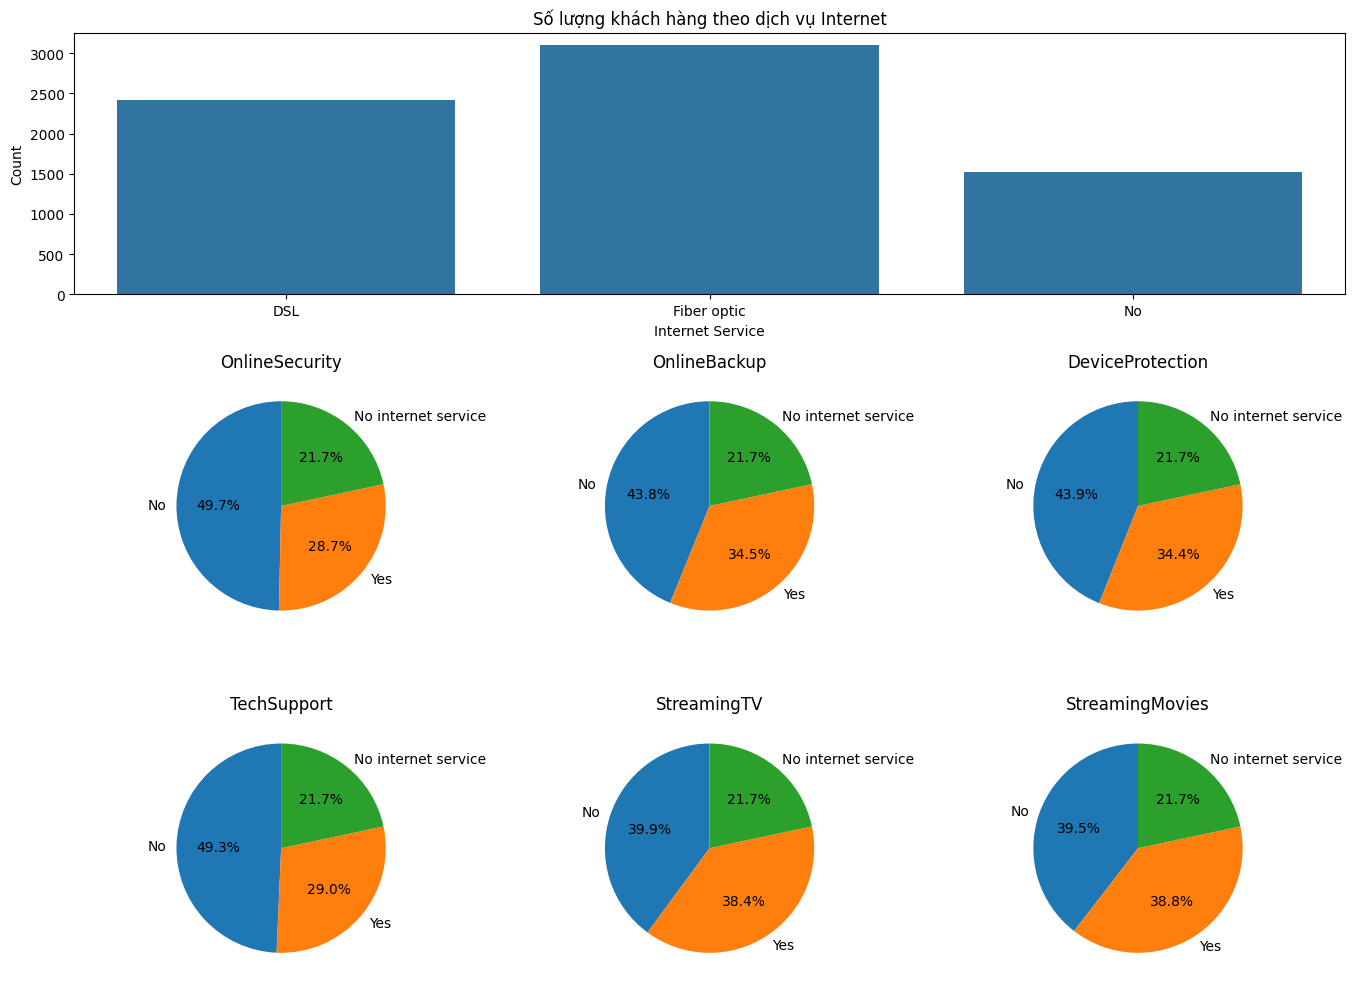

In [ ]:
fig = plt.figure(figsize=(14, 10))

ax1 = plt.subplot2grid((3, 3), (0, 0), colspan=3)

sns.countplot(
    x='InternetService',
    data=df,
    ax=ax1
)

ax1.set_title('Số lượng khách hàng theo dịch vụ Internet')
ax1.set_xlabel('Internet Service')
ax1.set_ylabel('Count')

cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for i, col in enumerate(cols):
    ax = plt.subplot2grid((3, 3), ((i // 3) + 1, i % 3))

    data = df[col].value_counts(normalize=True) * 100

    ax.pie(
        data,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90
    )
    ax.set_title(col)

plt.tight_layout()
plt.show()

Dựa vào biểu đồ cho thấy lượng người sử dụng dịch vụ Internet là cao nhất, sau đó đến người sử dụng DSL và số người không sử dụng dịch vụ Internet cũng rất cao.
* Tỷ lệ sử dụng các dịch vụ hỗ trợ còn thấp: Trong các mảng như OnlineSecurity, TechSupport, và DeviceProtection, tỷ lệ khách hàng trả lời "No" chiếm ưu thế tuyệt đối (gần 50%). Điều này gợi ý rằng khách hàng chưa thực sự quan tâm hoặc chưa thấy được giá trị của các gói bảo mật và hỗ trợ kỹ thuật.

* Xu hướng giải trí mạnh mẽ: Ngược lại, ở hai mảng Streaming TV và Streaming Movies, tỷ lệ khách hàng sử dụng ("Yes") cao hơn hẳn (đạt mức 38.4% và 38.8%). Khách hàng sẵn sàng chi tiền cho nhu cầu giải trí nhiều hơn là các dịch vụ bảo vệ.

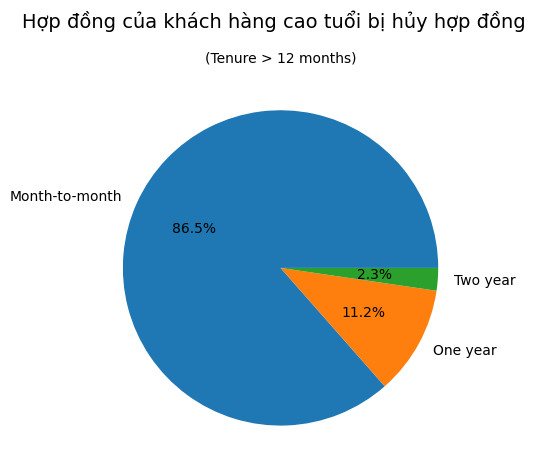

In [ ]:
data = df[
    (df['Churn'] == 'Yes') &
    (df['SeniorCitizen'] == 1) &
    (df['tenure'] > 12)
]['Contract'].value_counts()

plt.pie(data, autopct='%1.1f%%', labels=data.index)
plt.suptitle('Hợp đồng của khách hàng cao tuổi bị hủy hợp đồng', fontsize=14)
plt.title('(Tenure > 12 months)', fontsize=10)
plt.tight_layout()
plt.show()

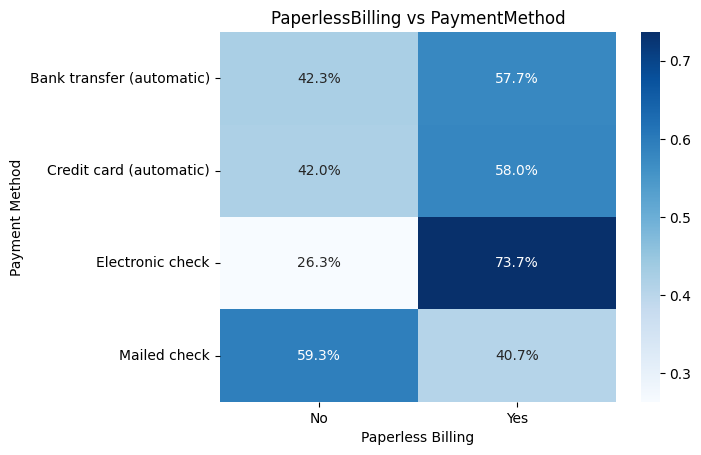

In [ ]:
data = (
    df.groupby(['PaymentMethod', 'PaperlessBilling'])
      .size()
      .unstack(fill_value=0)
)

data_percent = data.div(data.sum(axis=1), axis=0)

sns.heatmap(
    data_percent,
    annot=True,
    fmt=".1%",
    cmap="Blues"
)

plt.title('PaperlessBilling vs PaymentMethod')
plt.xlabel('Paperless Billing')
plt.ylabel('Payment Method')
plt.show()

## Biến số

In [ ]:
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

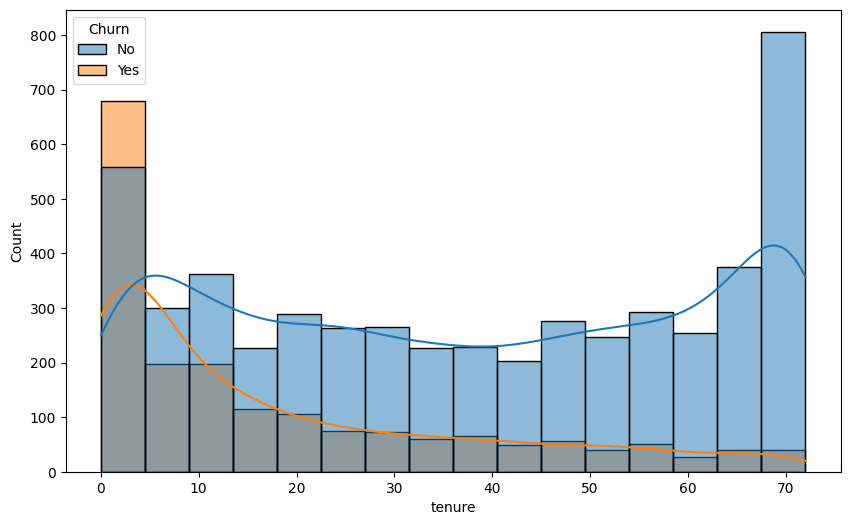

In [ ]:
# tenure
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', kde=True, hue='Churn')
plt.show()



*   Biểu đồ này cho thấy với 5 tháng đầu tiên thì số lượng khách đăng ký dịch nhiều nhưng rời đi cũng khá nhiều.
*   Sau giai đoạn 'sàng lọc' này, từ tháng thứ 6 trở đi, mặc dù tổng lượng khách giảm nhưng tỷ lệ người ở lại trở nên ổn định và áp đảo hoàn toàn nhóm rời đi.

*   Đường KDE cho thấy rõ xu hướng: rủi ro rời bỏ giảm dần theo thời gian và khách hàng có xu hướng cực kỳ trung thành nếu đã gắn bó trên 60-70 tháng.





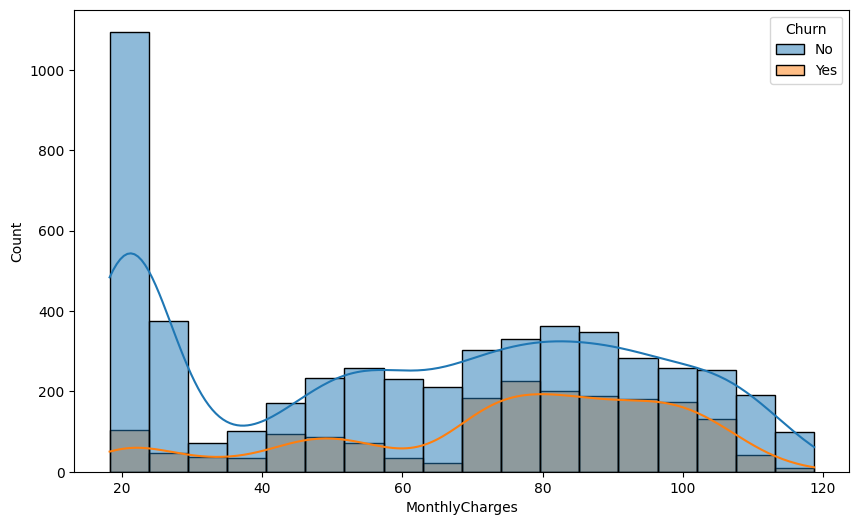

In [ ]:
# MonthlyCharges
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='MonthlyCharges', kde=True, hue='Churn')
plt.show()

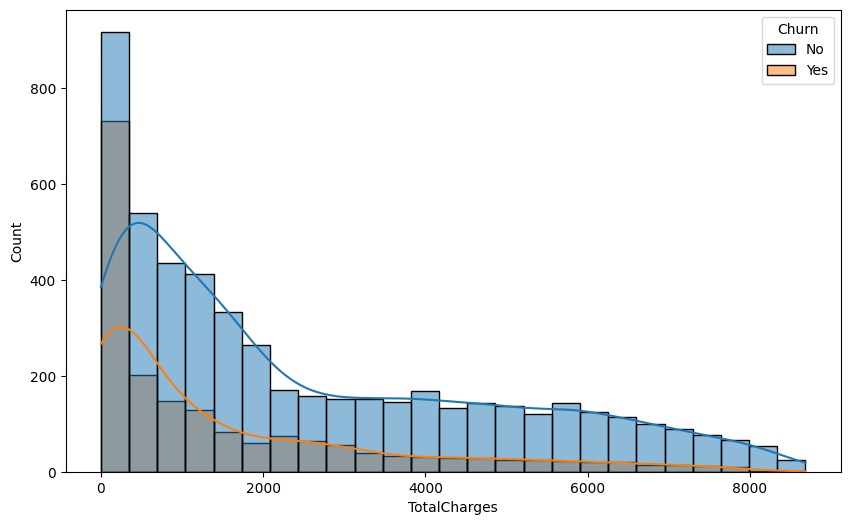

In [ ]:
# TotalCharges
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='TotalCharges', kde=True, hue='Churn')
plt.show()

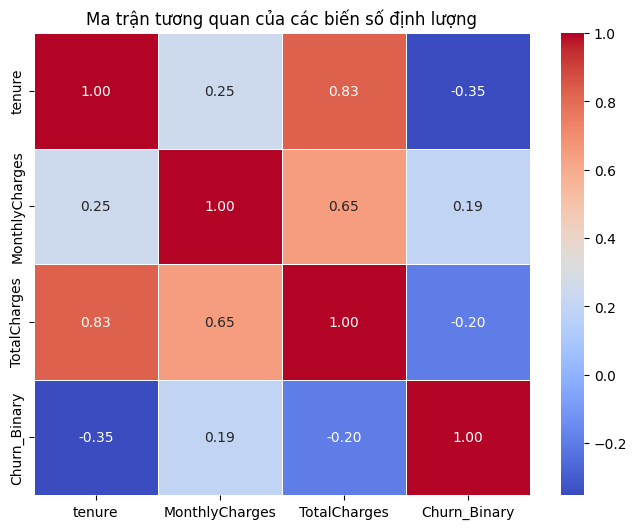

In [ ]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan của các biến số định lượng')
plt.show()

# Thực nghiệm

## Chuẩn bị dữ liệu

In [ ]:
data = df.copy()

X = data.drop(columns=['customerID', 'Churn', 'Churn_Binary'])
y = data['Churn'].map({'Yes': 1, 'No': 0})

X = pd.get_dummies(X, drop_first=True, dtype=int)

X.dtypes

,0
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64
gender_Male,int64
Partner_Yes,int64
Dependents_Yes,int64
PhoneService_Yes,int64
MultipleLines_No phone service,int64
MultipleLines_Yes,int64


In [ ]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,1,1,1,0,1,...,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,1,1,1,0,1,...,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,1,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,1


## Chọn mô hình và chia bộ dữ liệu

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
scales = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scales.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scales.transform(X_test[num_cols])

In [ ]:
X_train_scaled[num_cols]

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
3738,-0.441773,0.102371,-0.521976,-0.262257
3151,-0.441773,-0.711743,0.337478,-0.503635
4860,-0.441773,-0.793155,-0.809013,-0.749883
3867,-0.441773,-0.263980,0.284384,-0.172722
3810,-0.441773,-1.281624,-0.676279,-0.989374
...,...,...,...,...
6303,-0.441773,1.567778,1.470695,2.373129
6227,-0.441773,-1.240918,-0.626504,-0.973665
4673,2.263606,-0.304686,1.256662,0.158344
2710,-0.441773,-0.345392,-1.477661,-0.797075


### LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled, y_train)
y_pred_logis = logistic_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Tỷ lệ dự đoán đúng của mô hình
print('Accuracy Logistic: ', accuracy_score(y_test, y_pred_logis))

# Bảng nhầm lẫn
print('Confusion Matrix Logistic:\n', confusion_matrix(y_test, y_pred_logis))

# Báo cáo phân loại
print('Classification Report Logistic:\n', classification_report(y_test, y_pred_logis))

Accuracy Logistic:  0.8069552874378992
Confusion Matrix Logistic:
 [[927 108]
 [164 210]]
Classification Report Logistic:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### KNeighborsClassifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

In [ ]:
print('Accuracy knn: ', accuracy_score(y_test, y_pred_knn))
print('Confusion Matrix knn:\n', confusion_matrix(y_test, y_pred_knn))
print('Classification knn:\n', classification_report(y_test, y_pred_knn))

Accuracy knn:  0.7665010645848119
Confusion Matrix knn:
 [[869 166]
 [163 211]]
Classification knn:
               precision    recall  f1-score   support

           0       0.84      0.84      0.84      1035
           1       0.56      0.56      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



### Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)

In [ ]:
print('Accuracy nb: ', accuracy_score(y_test, y_pred_nb))
print('Confusion Matrix nb:\n', confusion_matrix(y_test, y_pred_nb))
print('Classification nb:\n', classification_report(y_test, y_pred_nb))

Accuracy nb:  0.6557842441447835
Confusion Matrix nb:
 [[600 435]
 [ 50 324]]
Classification nb:
               precision    recall  f1-score   support

           0       0.92      0.58      0.71      1035
           1       0.43      0.87      0.57       374

    accuracy                           0.66      1409
   macro avg       0.67      0.72      0.64      1409
weighted avg       0.79      0.66      0.67      1409



### DecisionTree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [ ]:
print('Accuracy dt: ', accuracy_score(y_test, y_pred_dt))
print('Confusion Matrix dt:\n', confusion_matrix(y_test, y_pred_dt))
print('Classification dt:\n', classification_report(y_test, y_pred_dt))

Accuracy dt:  0.7374024130589071
Confusion Matrix dt:
 [[854 181]
 [189 185]]
Classification dt:
               precision    recall  f1-score   support

           0       0.82      0.83      0.82      1035
           1       0.51      0.49      0.50       374

    accuracy                           0.74      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.74      0.74      0.74      1409



### XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:09:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
print("Accuracy (XGB):", accuracy_score(y_test, y_pred_xgb))
print("Confusion Matrix (XGB):\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report (XGB):\n", classification_report(y_test, y_pred_xgb))

Accuracy (XGB): 0.8005677785663591
Confusion Matrix (XGB):
 [[933 102]
 [179 195]]
Classification Report (XGB):
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Accuracy rf:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix rf:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report rf:\n", classification_report(y_test, y_pred_rf))

Accuracy rf: 0.7636621717530163
Confusion Matrix rf:
 [[805 230]
 [103 271]]
Classification Report rf:
               precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



In [ ]:
models_pred = {
    'LogisticRegression': y_pred_logis,
    'KNeighborsClassifier': y_pred_knn,
    'GaussianNB': y_pred_nb,
    'DecisionTreeClassifier': y_pred_dt,
    'XGBClassifier': y_pred_xgb,
    'RandomForestClassifier': y_pred_rf
}

results = []
for model_name, y_pred in models_pred.items():
  acc = accuracy_score(y_test, y_pred)
  report = classification_report(y_test, y_pred, output_dict=True)
  results.append({
      'Model': model_name,
      'Accuracy': acc,
      'Precision': report['1']['precision'],
      'Recall': report['1']['recall'],
      'F1-score': report['1']['f1-score']
  })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,LogisticRegression,0.806955,0.660377,0.561497,0.606936
1,KNeighborsClassifier,0.766501,0.559682,0.564171,0.561917
2,GaussianNB,0.655784,0.426877,0.866310,0.571933
3,DecisionTreeClassifier,0.737402,0.505464,0.494652,0.500000
4,XGBClassifier,0.800568,0.656566,0.521390,0.581222
5,RandomForestClassifier,0.763662,0.540918,0.724599,0.619429


Chọn Random Forest làm mô hình tối ưu vì nó có F1-score cao nhất (0.619). Điều này chứng tỏ Random Forest là mô hình có khả năng dung hòa tốt nhất: vừa bắt được lượng lớn khách hàng thực sự rời đi, vừa hạn chế được tối đa việc dự báo nhầm gây lãng phí chi phí chăm sóc khách hàng.